<a href="https://colab.research.google.com/github/julieatkeson/julieandliv/blob/main/julieandliv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Julie Atkeson and Liv __


## **Project Goals**

This project aims to examine how students' economic backgrounds influence their likelihood of enrolling in college in the United States as atuition costs continue to rise. We will also evaluate whether financial aid programs are effectively reducing the financial burden on lower and middle income students and improving their ability to enroll.

## **Collaboration Plan**

Our team will meet weekly to coordinate progress, review each other's work, and address any challenges that arise. Between meetings, we will communicate through chat for quick updates and questions. We will keep a shared notes doc to keep track of tasks we need to get done. All code will be developed collaboratively in a shared Google Colab notebook.

## **Table 1**

In [6]:
import pandas as pd
income_gap_df = pd.read_csv('uscensus.csv')

In [7]:
income_gap_df.head(10)

,PERIDNUM,PH_SEQ,PXTLWK,PXTLWKHR,PTTLWK,PTTLWKHR,P_SEQ,A_LINENO,PF_SEQ,PHF_SEQ,...,I_SURVL1,I_SURVL2,MIG_CBST,MIG_DSCP,M5G_CBST,M5G_DSCP,DEP_STAT,FILEDATE,FILESTAT,YYYYMM
0,8519008061493221701101,1,0,0,0,0,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72825.0,6.0,202503.0
1,8519008061493221701102,1,0,0,0,0,2,2,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72825.0,6.0,202503.0
2,5340801058562911701101,10,0,0,0,0,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72825.0,6.0,202503.0
3,0920940526130571701101,11,0,0,0,0,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72825.0,5.0,202503.0
4,0620890076139291801101,13,0,0,1,46,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72825.0,1.0,202503.0
5,0620890076139291801102,13,0,0,1,43,2,2,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72825.0,1.0,202503.0
6,0620890076139291801103,13,0,0,0,0,3,3,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,72825.0,6.0,202503.0
7,0620890076139291801104,13,0,0,0,0,4,4,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,72825.0,6.0,202503.0
8,1708069003299621801101,14,0,0,1,40,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72825.0,1.0,202503.0
9,1708069003299621801102,14,0,-1,2,-1,2,2,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72825.0,1.0,202503.0


In [12]:
income_gap_df = income_gap_df.rename(columns={
    'PTOT_R': 'total_income_bracket',
    'A_HSCOL': 'enrollment_status',
    'PH_SEQ': 'household_id'
})

In [13]:
enrolled_df = income_gap_df[income_gap_df['enrollment_status'].isin([1, 2])].copy()
enrolled_df['college_enrolled'] = (enrolled_df['enrollment_status'] == 2).astype(int)

enrollment_by_income = enrolled_df.groupby('total_income_bracket')['college_enrolled'].mean().reset_index()
enrollment_by_income.columns = ['total_income_bracket', 'college_enrollment_rate']

print(enrollment_by_income)

    total_income_bracket  college_enrollment_rate
0                    1.0                 0.367965
1                    2.0                 0.448980
2                    3.0                 0.591667
3                    4.0                 0.701493
4                    5.0                 0.590909
5                    6.0                 0.659091
6                    7.0                 0.772727
7                    8.0                 0.687500
8                    9.0                 0.964286
9                   10.0                 1.000000
10                  11.0                 0.891892
11                  12.0                 0.857143
12                  13.0                 0.911765
13                  14.0                 0.846154
14                  15.0                 0.764706
15                  16.0                 1.000000
16                  17.0                 1.000000
17                  18.0                 0.714286
18                  19.0                 0.933333


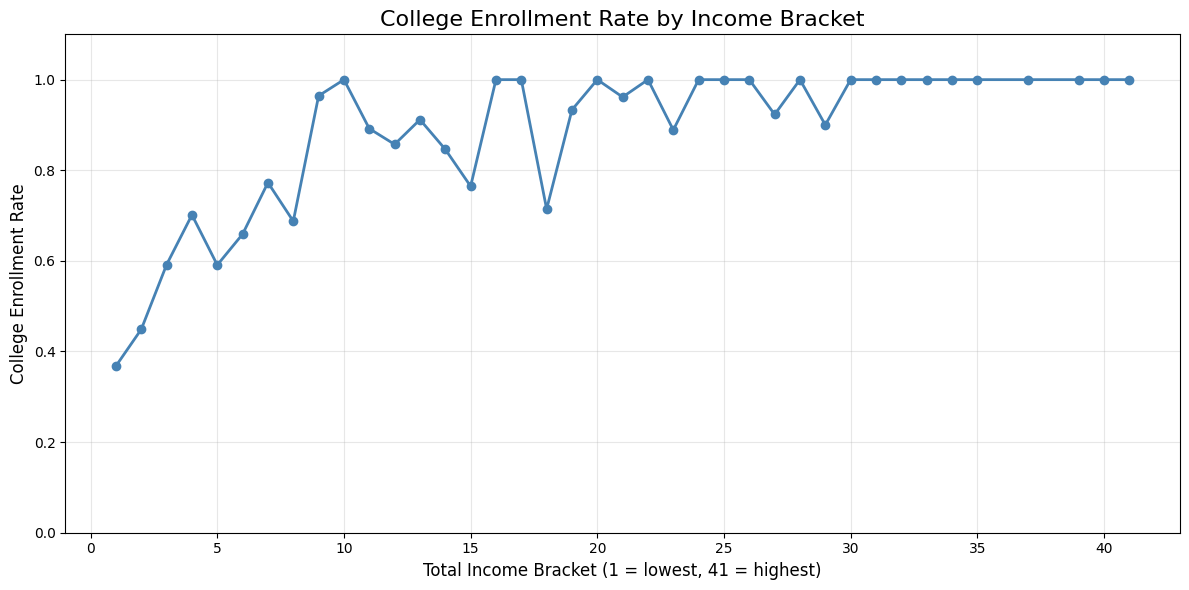

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(enrollment_by_income['total_income_bracket'],
         enrollment_by_income['college_enrollment_rate'],
         marker='o', color='steelblue', linewidth=2)

plt.title('College Enrollment Rate by Income Bracket', fontsize=16)
plt.xlabel('Total Income Bracket (1 = lowest, 41 = highest)', fontsize=12)
plt.ylabel('College Enrollment Rate', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Table 2**

In [ ]:
financial_aid = pd.read_csv('collegescorecard.csv')